# Ridge movement gating

Load stored inference/forecast parquets (no model re-run).
Build Ridge: ECoG features -> movement state `s` (vx > 5th-pct of train).
Multiply test predictions by `s_hat`, compare Pearson r before/after.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path("/home/bobby/repos/latent-neural-dynamics-modeling")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, roc_auc_score


## Config

In [2]:
DBS         = "both"
FORECAST_H  = "h0.5"
RIDGE_ALPHA = 1.0

PSID_DIR  = PROJECT_ROOT / f"results/psid/psid_z-as-behavior_PDI1_S4_nx_64_n1_8_dbs_{DBS}"
DPAD_DIR  = PROJECT_ROOT / f"results/dpad/dpad_z-as-behavior_PDI1_S4_nx_64_n1_4_e1000_dbs_{DBS}"
VARMA_DIR = PROJECT_ROOT / f"results/varma/varma_z-as-behavior_PDI1_S4_p30_q1_dbs_{DBS}"
print(PSID_DIR.name)


psid_z-as-behavior_PDI1_S4_nx_64_n1_8_dbs_both


## Helpers — load parquets

In [3]:
def stack_z(col):
    """Polars list-of-arrays column -> (T, n_z) ndarray."""
    return np.stack([np.array(v) for v in col])


def load_inference(run_dir, split):
    """Load inference/{split}/*.parquet. Returns list of dicts with Y, Z, Zp."""
    parquets = sorted((run_dir / f"inference/{split}").glob("*.parquet"))
    if not parquets:
        return []
    df = pl.read_parquet(parquets[0])
    out = []
    for row in df.iter_rows(named=True):
        out.append({
            "block": row["block"], "trial": row["trial"], "stim": row["stim"],
            "Y":  stack_z(row["Y"]),    # (T, n_y)
            "Z":  stack_z(row["Z"]),    # (T, n_z)  col 0 = vx
            "Zp": stack_z(row["Zp"]),   # (T, n_z)
        })
    return out


def load_forecast(run_dir, split, h=FORECAST_H):
    """Load forecast/{h}/{split}/*.parquet. Returns list of dicts."""
    parquets = sorted((run_dir / f"forecast/{h}/{split}").glob("*.parquet"))
    if not parquets:
        print(f"  no forecast parquets in {run_dir.name}/forecast/{h}/{split}")
        return []
    df = pl.read_parquet(parquets[0])
    out = []
    for row in df.iter_rows(named=True):
        out.append({
            "block": row["block"], "trial": row["trial"], "stim": row["stim"],
            "Z_true": stack_z(row["Z_future_true"]),  # (m, n_z)
            "Z_pred": stack_z(row["Z_future_pred"]),  # (m, n_z)
            "Y_hist": stack_z(row["Y"]),              # (h_samples, n_y)
        })
    return out


## Load train split for Ridge

In [4]:
SFREQ = 200

def load_split(split_dir, split, y_features, z_features):
    """Load a split parquet, trim margins, return (Y_list, Z_list)."""
    df = pl.read_parquet(Path(split_dir) / f"{split}.parquet")
    Y_list, Z_list = [], []
    for row in df.iter_rows(named=True):
        cm = int(round(float(row["chunk_margin"]) * SFREQ))
        Y = np.column_stack([np.array(row[c]) for c in y_features])
        Z = np.column_stack([np.array(row[c]) for c in z_features])
        T = Y.shape[0]
        Y_list.append(Y[cm : T - cm])
        Z_list.append(Z)  # behavior has no margin
    return Y_list, Z_list

Y_FEATURES = [
    "ECOG_2_theta_4_8_raw", "ECOG_4_gamma_68_73_raw", "ECOG_3_gamma_73_78_raw",
    "ECOG_3_gamma_63_68_raw", "ECOG_4_gamma_53_58_raw", "ECOG_4_alpha_8_12_raw",
    "ECOG_1_gamma_37_42_env", "ECOG_3_theta_4_8_env", "ECOG_3_beta_13_18_env",
    "ECOG_3_gamma_68_73_env", "ECOG_2_gamma_42_47_env", "ECOG_3_gamma_78_83_env",
]
Z_FEATURES = ["tracing_velocity_x", "tracing_acceleration_magnitude"]

Y_train, Z_train = load_split(PSID_DIR / "split", "train", Y_FEATURES, Z_FEATURES)
Y_test_sp, Z_test_sp = load_split(PSID_DIR / "split", "test",  Y_FEATURES, Z_FEATURES)

print(f"train: {len(Y_train)} trials  Y0={Y_train[0].shape}  Z0={Z_train[0].shape}")
print(f"test:  {len(Y_test_sp)} trials")
print(f"Z features: {Z_FEATURES}")


train: 48 trials  Y0=(1800, 12)  Z0=(1800, 2)
test:  45 trials
Z features: ['tracing_velocity_x', 'tracing_acceleration_magnitude']


## Build Ridge: ECoG -> movement state s

In [5]:
all_vx_train = np.concatenate([Z[:, 0] for Z in Z_train])
VX_THRESH = np.percentile(np.abs(all_vx_train), 5)
print(f"vx magnitude 5th-pct threshold = {VX_THRESH:.2f}")

X_tr = np.concatenate(Y_train, axis=0)
s_tr = (np.abs(np.concatenate([Z[:, 0] for Z in Z_train])) > VX_THRESH).astype(float)
print(f"Ridge train: X={X_tr.shape}  movement_frac={s_tr.mean():.3f}")

scaler = StandardScaler().fit(X_tr)
ridge  = Ridge(alpha=RIDGE_ALPHA).fit(scaler.transform(X_tr), s_tr)


vx magnitude 5th-pct threshold = 8.82
Ridge train: X=(86400, 12)  movement_frac=0.950


## Ridge evaluation on test split

Ridge test (movement gate):
  R2           = 0.0619
  balanced acc = 0.5000
  AUC-ROC      = 0.7530
  movement frac test = 0.837


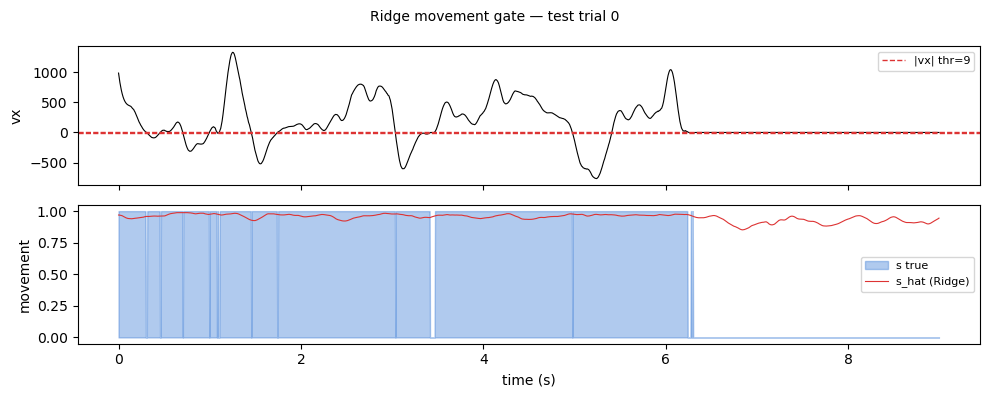

In [6]:
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

X_te_sp = np.concatenate(Y_test_sp, axis=0)
s_te_sp = (np.abs(np.concatenate([Z[:, 0] for Z in Z_test_sp])) > VX_THRESH).astype(float)

s_hat_te = ridge.predict(scaler.transform(X_te_sp))
s_hat_te_bin = (s_hat_te > 0.5).astype(float)

r2  = 1 - np.var(s_te_sp - s_hat_te) / np.var(s_te_sp)
ba  = balanced_accuracy_score(s_te_sp, s_hat_te_bin)
auc = roc_auc_score(s_te_sp, s_hat_te)
print(f'Ridge test (movement gate):')
print(f'  R2           = {r2:.4f}')
print(f'  balanced acc = {ba:.4f}')
print(f'  AUC-ROC      = {auc:.4f}')
print(f'  movement frac test = {s_te_sp.mean():.3f}')

# per-trial plot: s_hat vs s_true on first test trial
Y0, Z0 = Y_test_sp[0], Z_test_sp[0]
s_hat0 = np.clip(ridge.predict(scaler.transform(Y0)), 0, 1)
s_true0 = (np.abs(Z0[:, 0]) > VX_THRESH).astype(float)
t_ax = np.arange(len(Z0)) / SFREQ

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axes[0].plot(t_ax, Z0[:, 0], color='k', lw=0.8)
axes[0].axhline( VX_THRESH, color='#d33', lw=1, ls='--', label=f'|vx| thr={VX_THRESH:.0f}')
axes[0].axhline(-VX_THRESH, color='#d33', lw=1, ls='--')
axes[0].set_ylabel('vx'); axes[0].legend(loc='best', fontsize=8)
axes[1].fill_between(t_ax, s_true0, alpha=0.4, color='#3a7bd5', label='s true')
axes[1].plot(t_ax, s_hat0, color='#d33', lw=0.8, label='s_hat (Ridge)')
axes[1].set_ylabel('movement'); axes[1].set_xlabel('time (s)')
axes[1].legend(loc='best', fontsize=8)
fig.suptitle('Ridge movement gate — test trial 0', fontsize=10)
fig.tight_layout()
plt.show()


## Load stored 1-step predictions

In [7]:
psid_test  = load_inference(PSID_DIR,  "test")
dpad_test  = load_inference(DPAD_DIR,  "test")
varma_test = load_inference(VARMA_DIR, "test")
print(f"test trials: PSID={len(psid_test)}, DPAD={len(dpad_test)}, VARMA={len(varma_test)}")

# index DPAD/VARMA by (block, trial) for alignment with PSID Y
dpad_lu  = {(t["block"], t["trial"]): t for t in dpad_test}
varma_lu = {(t["block"], t["trial"]): t for t in varma_test}


test trials: PSID=45, DPAD=45, VARMA=45


## Gate 1-step predictions

In [8]:
def pearson(a, b):
    if a.std() < 1e-9 or b.std() < 1e-9:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])


results_1step = {m: {"r_raw": [], "r_gated": []} for m in ("PSID", "DPAD", "VARMA")}

for t_psid in psid_test:
    key = (t_psid["block"], t_psid["trial"])
    Y   = t_psid["Y"]
    s_hat = np.clip(ridge.predict(scaler.transform(Y)), 0, 1)

    for label, t in [("PSID", t_psid), ("DPAD", dpad_lu.get(key)), ("VARMA", varma_lu.get(key))]:
        if t is None:
            continue
        T   = min(Y.shape[0], t["Zp"].shape[0])
        vx  = t["Z"][:T, 0]
        zp  = t["Zp"][:T, 0]
        s   = s_hat[:T]
        results_1step[label]["r_raw"].append(pearson(vx, zp))
        results_1step[label]["r_gated"].append(pearson(vx * s, zp * s))

print("1-step test (vx channel):")
for label, v in results_1step.items():
    rr = np.nanmean(v["r_raw"]); rg = np.nanmean(v["r_gated"])
    print(f"  {label:5s}  r_raw={rr:.4f}  r_gated={rg:.4f}  delta={rg-rr:+.4f}")


1-step test (vx channel):
  PSID   r_raw=0.0475  r_gated=0.0450  delta=-0.0026
  DPAD   r_raw=0.0192  r_gated=0.1024  delta=+0.0833
  VARMA  r_raw=0.9999  r_gated=0.9999  delta=+0.0000


## Load stored m-step predictions

In [9]:
psid_fc  = load_forecast(PSID_DIR,  "test")
dpad_fc  = load_forecast(DPAD_DIR,  "test")
varma_fc = load_forecast(VARMA_DIR, "test")
print(f"forecast trials: PSID={len(psid_fc)}, DPAD={len(dpad_fc)}, VARMA={len(varma_fc)}")


forecast trials: PSID=45, DPAD=27, VARMA=45


## Gate m-step predictions

In [10]:
results_fc = {m: {"r_raw": [], "r_gated": []} for m in ("PSID", "DPAD", "VARMA")}

for label, fc_list in [("PSID", psid_fc), ("DPAD", dpad_fc), ("VARMA", varma_fc)]:
    for t in fc_list:
        # scalar gate: mean s_hat over history window
        s_gate = float(np.clip(ridge.predict(scaler.transform(t["Y_hist"])), 0, 1).mean())
        vx_true = t["Z_true"][:, 0]
        vx_pred = t["Z_pred"][:, 0]
        results_fc[label]["r_raw"].append(pearson(vx_true, vx_pred))
        results_fc[label]["r_gated"].append(pearson(vx_true * s_gate, vx_pred * s_gate))

print(f"m-step forecast ({FORECAST_H}, vx channel):")
for label, v in results_fc.items():
    rr = np.nanmean(v["r_raw"]); rg = np.nanmean(v["r_gated"])
    print(f"  {label:5s}  r_raw={rr:.4f}  r_gated={rg:.4f}  delta={rg-rr:+.4f}")


m-step forecast (h0.5, vx channel):
  PSID   r_raw=-0.0140  r_gated=-0.0140  delta=+0.0000
  DPAD   r_raw=0.0112  r_gated=0.0112  delta=+0.0000
  VARMA  r_raw=0.1849  r_gated=0.1849  delta=-0.0000


## Summary plot

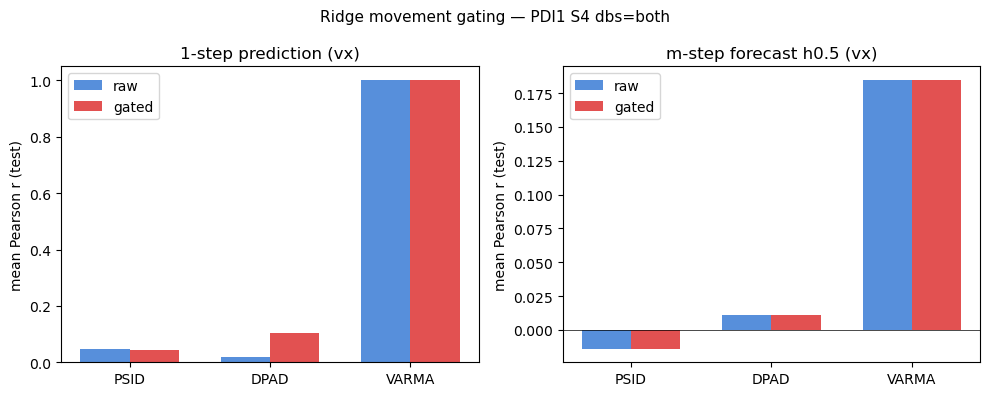

In [11]:
models = ["PSID", "DPAD", "VARMA"]
x, w   = np.arange(len(models)), 0.35

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, res, title in [
    (axes[0], results_1step, "1-step prediction (vx)"),
    (axes[1], results_fc,    f"m-step forecast {FORECAST_H} (vx)"),
]:
    r_r = [np.nanmean(res[m]["r_raw"])   for m in models]
    r_g = [np.nanmean(res[m]["r_gated"]) for m in models]
    ax.bar(x - w/2, r_r, w, label="raw",   color="#3a7bd5", alpha=0.85)
    ax.bar(x + w/2, r_g, w, label="gated", color="#d33",    alpha=0.85)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(models)
    ax.set_ylabel("mean Pearson r (test)")
    ax.set_title(title)
    ax.legend(loc="best")
fig.suptitle(f"Ridge movement gating — PDI1 S4 dbs={DBS}", fontsize=11)
fig.tight_layout()
plt.show()
